In [2]:
!python eval_v2/core/hydra_launcher.py --multirun \
  hydra/launcher=basic hydra/output=local \
  hydra.sweep.subdir='job_${hydra.job.num}' \
  device=cuda \
  eval_frequency=1000 \
  env=kitchen_knob1_on-v3 \
  camera=left_cap2 \
  pixel_based=true \
  embedding=resnet50 \
  num_demos=1 \
  env_kwargs.load_path=r3m \
  bc_kwargs.finetune=false \
  proprio=9 \
  job_name=r3m_eval_num_1_285k

/home/xli990/paichichi/GitHub/r3m_v2/evaluation_v2/eval_v2/core/hydra_launcher.py:21: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_name="BC_config", config_path="config")
/home/xli990/miniconda3/envs/eval_set_v2/lib/python3.11/site-packages/hydra/_internal/core_plugins/basic_launcher.py:74: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See https://hydra.cc/docs/1.2/upgrades/1.1_to_1.2/changes_to_job_working_dir/ for more information.
  ret = run_job(
Job Configuration
requested device: cuda
selected device : cuda
torch version   : 2.10.0+cu128
cuda available  : True
cuda device cnt : 1
cuda name[0]    : NVIDIA GeForce RTX 5090
mps available   : False
1
Demonstration score : -29.87 
{'env_name': 'kitchen_knob1_on-v3', 'device': 'cuda', 'image_width': 256, 'image_height': 256, 'camera_name': 'left_cap2', 'em

In [1]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def parse_eval_blocks(file_path, version_name="V1"):
    file_path = Path(file_path)

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [line.rstrip("\n") for line in f]

    records = []
    i = 0
    n = len(lines)

    while i < n:
        line = lines[i].strip()

        if line == "Evaluating":
            block_start = i

            record = {
                "version": version_name,
                "block_start_line": block_start + 1,  # 更符合人类习惯，行号从1开始
                "epoch": np.nan,
                "eval_epoch": np.nan,
                "eval_success": np.nan,
                "loss_after": np.nan,
                "loss_before": np.nan,
                "time": np.nan,
            }

            j = i + 1

            # 往后扫描，直到下一个 Evaluating 或文件结束
            while j < n:
                cur = lines[j].strip()

                if cur == "Evaluating" and j != i + 1:
                    break

                # 匹配类似:
                # epoch            1
                # loss_after       7.51062e-05
                m = re.match(r"^(epoch|eval_epoch|eval_success|loss_after|loss_before|time)\s+(.+)$", cur)
                if m:
                    key = m.group(1)
                    value = m.group(2).strip()

                    if key in ["epoch", "eval_epoch"]:
                        try:
                            record[key] = int(float(value))
                        except:
                            record[key] = np.nan
                    else:
                        try:
                            record[key] = float(value)
                        except:
                            record[key] = np.nan

                j += 1

            # 只有6个字段至少都找到了再收下
            required = ["epoch", "eval_epoch", "eval_success", "loss_after", "loss_before", "time"]
            if all(pd.notna(record[k]) for k in required):
                records.append(record)

            i = j
        else:
            i += 1

    df = pd.DataFrame(records)

    if not df.empty:
        df["iter_idx"] = np.arange(len(df))
        df["loss_gap"] = df["loss_before"] - df["loss_after"]
        df["loss_ratio"] = df["loss_after"] / (df["loss_before"] + 1e-12)
        df["log10_loss_before"] = np.log10(df["loss_before"] + 1e-20)
        df["log10_loss_after"] = np.log10(df["loss_after"] + 1e-20)

    return df

In [3]:
v1_path = "V1_log.txt"
v2_path = "V2_log.txt"

df_v1 = parse_eval_blocks(v1_path, version_name="V1_old_env")
df_v2 = parse_eval_blocks(v2_path, version_name="V2_new_env")

print("V1 成功解析:", len(df_v1), "个 evaluating blocks")
print("V2 成功解析:", len(df_v2), "个 evaluating blocks")

V1 成功解析: 8 个 evaluating blocks
V2 成功解析: 0 个 evaluating blocks


In [5]:
df_v2

""


In [4]:
df_all = pd.concat([df_v1, df_v2], ignore_index=True)
display(df_all.head())

""


In [12]:
df_all = pd.concat([df_v1, df_v2], ignore_index=True)
display(df_all.head())

""


In [1]:
import os
import numpy as np

# 必须在 import mujoco/gymnasium 之前设置
os.environ.setdefault("MUJOCO_GL", "egl")  # 或者 osmesa

import gymnasium as gym
import gymnasium_robotics

def run_one_episode(task="microwave", max_steps=60, seed=123, render=True):
    gym.register_envs(gymnasium_robotics)

    env = gym.make(
        "FrankaKitchen-v1",
        tasks_to_complete=[task],
        render_mode="rgb_array",
        width=256,
        height=256,
    )

    obs, info = env.reset(seed=seed)

    solved_seq = []
    done_seq = []
    r_dense_seq = []
    r_sparse_seq = []

    # 先渲染一帧看看
    if render:
        img = env.render()
        img = np.asarray(img)
        print("[render] img shape:", img.shape, "mean:", img.mean(), "std:", img.std())

    for t in range(max_steps):
        action = env.action_space.sample()

        out = env.step(action)
        # gymnasium: obs, reward, terminated, truncated, info
        obs, reward, terminated, truncated, info = out

        # 打印一次 keys（只在第一步）
        if t == 0:
            print("[info keys]", info.keys())

        # 关键：看 solved 是否存在
        solved = info.get("solved", None)
        if solved is None:
            # 有些环境可能用 is_success / success
            solved = info.get("is_success", info.get("success", None))

        solved_seq.append(bool(solved) if solved is not None else False)

        # 额外记录 reward（如果有）
        if "rwd_dense" in info:
            r_dense_seq.append(float(info["rwd_dense"]))
        if "rwd_sparse" in info:
            r_sparse_seq.append(float(info["rwd_sparse"]))
        if "done" in info:
            done_seq.append(bool(info["done"]))
        else:
            done_seq.append(bool(terminated or truncated))

        if terminated or truncated:
            print(f"[episode done] t={t}, terminated={terminated}, truncated={truncated}")
            break

    env.close()

    solved_seq = np.asarray(solved_seq, dtype=np.bool_)
    print("[solved] first 10:", solved_seq[:10], " last 10:", solved_seq[-10:])
    # 老环境的成功判定：sum(solved) > successful_steps
    successful_steps = 5
    success = (np.sum(solved_seq * 1.0) > successful_steps)
    print(f"[success] sum(solved)={np.sum(solved_seq)}, threshold={successful_steps}, success={success}")

    if len(r_dense_seq) > 0:
        print("[rwd_dense] mean:", float(np.mean(r_dense_seq)), "last:", r_dense_seq[-1])
    if len(r_sparse_seq) > 0:
        print("[rwd_sparse] mean:", float(np.mean(r_sparse_seq)), "last:", r_sparse_seq[-1])

    return {
        "solved_seq": solved_seq,
        "success": bool(success),
    }

def run_n_episodes(n=5, task="microwave", max_steps=60, seed=123):
    results = []
    for i in range(n):
        print("\n" + "=" * 60)
        print(f"Episode {i} (seed={seed+i}) task={task}")
        ret = run_one_episode(task=task, max_steps=max_steps, seed=seed+i, render=(i == 0))
        results.append(ret["success"])

    success_rate = 100.0 * np.mean(results)
    print("\n" + "=" * 60)
    print(f"[final] n={n}, success_rate={success_rate:.2f}%")
    return success_rate

if __name__ == "__main__":
    # 单任务验证
    run_n_episodes(n=3, task="microwave", max_steps=60, seed=123)


Episode 0 (seed=123) task=microwave
[render] img shape: (256, 256, 3) mean: 108.4351094563802 std: 64.54121308966224
[info keys] dict_keys(['tasks_to_complete', 'step_task_completions', 'episode_task_completions'])
[solved] first 10: [False False False False False False False False False False]  last 10: [False False False False False False False False False False]
[success] sum(solved)=0, threshold=5, success=False

Episode 1 (seed=124) task=microwave
[info keys] dict_keys(['tasks_to_complete', 'step_task_completions', 'episode_task_completions'])
[solved] first 10: [False False False False False False False False False False]  last 10: [False False False False False False False False False False]
[success] sum(solved)=0, threshold=5, success=False

Episode 2 (seed=125) task=microwave
[info keys] dict_keys(['tasks_to_complete', 'step_task_completions', 'episode_task_completions'])
[solved] first 10: [False False False False False False False False False False]  last 10: [False False 

In [3]:
import gymnasium as gym
ids = sorted([spec.id for spec in gym.envs.registry.values()])
# 打印包含 kitchen 的
for i in ids:
    if "kitchen" in i.lower() or "franka" in i.lower():
        print(i)
print("total envs:", len(ids))

total envs: 63


In [4]:
import importlib.util, sys
print("python:", sys.executable)
print("robotics installed:", importlib.util.find_spec("gymnasium_robotics") is not None)

python: /home/xli990/miniconda3/envs/eval_set_v2/bin/python
robotics installed: True


In [5]:
import gymnasium_robotics  # 触发注册
import gymnasium as gym

ids = sorted([spec.id for spec in gym.envs.registry.values()])
for i in ids:
    if "kitchen" in i.lower() or "franka" in i.lower():
        print(i)
print("total envs:", len(ids))

FrankaKitchen-v1
total envs: 280


In [6]:
import gymnasium as gym
import gymnasium_robotics  # 确保已注册

env = gym.make("FrankaKitchen-v1")
print(env)

# 尝试常见属性名（不同版本可能不一样）
for attr in ["tasks", "TASKS", "tasks_to_complete", "task_names", "possible_tasks"]:
    if hasattr(env, attr):
        print(attr, getattr(env, attr))

<TimeLimit<OrderEnforcing<PassiveEnvChecker<KitchenEnv<FrankaKitchen-v1>>>>>


In [7]:
import inspect
print(inspect.getsource(env.unwrapped.__class__))

class KitchenEnv(GoalEnv, EzPickle):
    """
    ## Description

    This environment was introduced in ["Relay policy learning: Solving long-horizon tasks via imitation and reinforcement learning"](https://arxiv.org/abs/1910.11956)
    by Abhishek Gupta, Vikash Kumar, Corey Lynch, Sergey Levine, Karol Hausman.

    The environment is based on the 9 degrees of freedom [Franka robot](https://www.franka.de/). The Franka robot is placed in a kitchen environment containing several common
    household items: a microwave, a kettle, an overhead light, cabinets, and an oven. The environment is a `multitask` goal in which the robot has to interact with the previously
    mentioned items in order to reach a desired goal configuration. For example, one such state is to have the microwave and sliding cabinet door open with the kettle on the top burner
    and the overhead light on. The goal tasks can be configured when the environment is created.

    ## Goal

    The goal has a multitask configu

In [5]:
from pathlib import Path

data_dir = Path("/home/xli990/paichichi/data/r3m/franka_kitchen-v1/")
print("exists:", data_dir.exists(), "is_dir:", data_dir.is_dir())
print("files:", len(list(data_dir.glob("*.pickle"))))

# 看看有哪些 demo 文件
for p in sorted(data_dir.glob("*.pickle"))[:20]:
    print(p.name, p.stat().st_size / (1024**2), "MB")

exists: True is_dir: True
files: 1
microwave.pickle 1931.850975036621 MB


In [8]:
import pickle
import numpy as np

demo_file = data_dir / "microwave.pickle"   # <- 改成你实际文件名
print("demo_file exists:", demo_file.exists(), demo_file)

demo_paths = pickle.load(open(demo_file, "rb"))
print("type(demo_paths):", type(demo_paths), "len:", len(demo_paths))

p0 = demo_paths[0]

print("env_infos keys:", p0["env_infos"].keys())
for k, v in p0["env_infos"].items():
    try:
        print(k, "type", type(v), "last", v[-1])
    except Exception:
        print(k, "type", type(v), "value", v)
print("path keys:", p0.keys())


# # 常见字段检查
# for k in ["actions", "rewards", "observations", "images", "env_infos"]:
#     if k in p0:
#         v = p0[k]
#         shape = getattr(np.asarray(v), "shape", None)
#         print(f"{k}: type={type(v)} shape={shape}")
#     else:
#         print(f"{k}: MISSING")

demo_file exists: True /home/xli990/paichichi/data/r3m/franka_kitchen-v1/microwave.pickle
type(demo_paths): <class 'list'> len: 200
env_infos keys: dict_keys(['time', 'rwd_dense', 'rwd_sparse', 'solved', 'done', 'obs_dict', 'rwd_dict', 'env_state'])
time type <class 'numpy.ndarray'> last 3.999999999999781
rwd_dense type <class 'numpy.ndarray'> last 0.8457800561069895
rwd_sparse type <class 'numpy.ndarray'> last -0.09228423746550624
solved type <class 'numpy.ndarray'> last True
done type <class 'numpy.ndarray'> last False
obs_dict type <class 'dict'> value {'t': array([0.08, 0.16, 0.24, 0.32, 0.4 , 0.48, 0.56, 0.64, 0.72, 0.8 , 0.88,
       0.96, 1.04, 1.12, 1.2 , 1.28, 1.36, 1.44, 1.52, 1.6 , 1.68, 1.76,
       1.84, 1.92, 2.  , 2.08, 2.16, 2.24, 2.32, 2.4 , 2.48, 2.56, 2.64,
       2.72, 2.8 , 2.88, 2.96, 3.04, 3.12, 3.2 , 3.28, 3.36, 3.44, 3.52,
       3.6 , 3.68, 3.76, 3.84, 3.92, 4.  ]), 'hand_jnt': array([[ 4.91657077e-02, -1.77037408e+00,  2.08255043e+00,
        -2.48756467e+00,

In [12]:
solved = demo_paths[0]["env_infos"]["solved"]
print(solved[:10], " ... ", solved[-10:])
print("first True index:", np.argmax(solved))  # 如果全 False，会返回 0

[False False False False False False False False False False]  ...  [ True  True  True  True  True  True  True  True  True  True]
first True index: 37


In [10]:
import gymnasium as gym
import gymnasium_robotics

# 注册 robotics env（有些版本需要）
gym.register_envs(gymnasium_robotics)

env = gym.make("FrankaKitchen-v1", tasks_to_complete=["microwave"])  # task 只是为了创建环境
obs, info = env.reset()

demo_act = np.asarray(p0["actions"])
demo_act_dim = demo_act.shape[-1]
env_act_dim = env.action_space.shape[0]

print("demo_act_dim:", demo_act_dim)
print("env_act_dim :", env_act_dim)
print("match:", demo_act_dim == env_act_dim)

demo_act_dim: 9
env_act_dim : 9
match: True


In [1]:
import gymnasium as gym
import gymnasium_robotics
import mujoco

gym.register_envs(gymnasium_robotics)

env = gym.make("FrankaKitchen-v1", tasks_to_complete=["microwave"], render_mode="rgb_array")
u = env.unwrapped

# gymnasium-robotics 的 env 通常会暴露 mujoco model（名称可能不同）
model = None
for attr in ["model", "_model", "mj_model"]:
    if hasattr(u, attr):
        model = getattr(u, attr)
        break

if model is None:
    # 某些实现把 model 挂在 sim/physics 上
    for attr in ["sim", "physics"]:
        if hasattr(u, attr) and hasattr(getattr(u, attr), "model"):
            model = getattr(u, attr).model
            break

print("model:", type(model))

cams = []
if model is not None and hasattr(model, "ncam"):
    for cam_id in range(model.ncam):
        name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_id)
        cams.append(name)
    print("num cameras:", len(cams))
    print(cams)
else:
    print("Could not access model.ncam; inspect env.unwrapped attributes:", dir(u)[:50])

model: <class 'mujoco._structs.MjModel'>
num cameras: 2
['left_cap', 'right_cap']


In [ ]:
import gymnasium as gym, gymnasium_robotics
import numpy as np
gym.register_envs(gymnasium_robotics)

def check(cam):
    env = gym.make("FrankaKitchen-v1", tasks_to_complete=["microwave"], render_mode="rgb_array")
    env.reset()
    # 有些实现不支持 camera_name 参数，只能在 render 时指定；先直接 render 看默认
    img = env.render()
    print("default render:", img.shape, img.mean(), img.std())
    env.close()

check("left_cap")

In [28]:
import os
os.environ["MUJOCO_GL"] = "egl"

import gymnasium as gym
import gymnasium_robotics

gym.register_envs(gymnasium_robotics)

env = gym.make(
    "FrankaKitchen-v1",
    tasks_to_complete=["microwave"],
    render_mode="rgb_array",
    width=256,
    height=256,
)

obs, info = env.reset()
img = env.render()
print(img.shape, img.mean(), img.std())

(256, 256, 3) 108.4351094563802 64.54121308966224


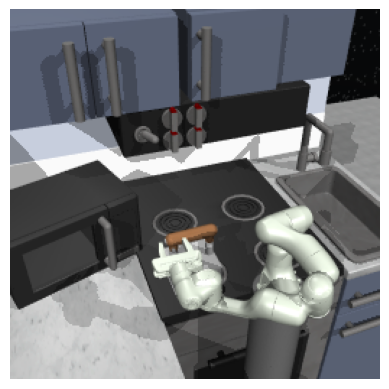

In [29]:
import matplotlib.pyplot as plt
plt.imshow(img)
plt.axis("off")
plt.show()